# Global Superstore Machine Learning Analysis
## Classification, Prediction and Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
df = pd.read_csv('Global_Superstore_Preprocessed.csv', encoding='latin-1')
print(f"Loaded {len(df)} rows")
df.head()

Loaded 51290 rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Discount,Profit,Shipping Cost,Order Priority,Shipping_Days,Order_Year,Order_Month,Order_Quarter,Profit_Margin,Profit_Category
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,0.0,762.1845,933.57,Critical,0,2012,7,3,33.000000,High Profit
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,0.1,-288.7650,923.63,Critical,2,2013,2,1,-7.784693,Loss
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,0.1,919.9710,915.49,Medium,1,2013,10,4,17.776630,High Profit
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,0.1,-96.5400,910.16,Medium,2,2013,1,1,-3.337586,Loss
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,0.0,311.5200,903.04,Critical,1,2013,11,4,10.996272,Medium Profit


## Part 1: Classification - Predict Profit Category

In [3]:
classification_features = ['Sales', 'Quantity', 'Discount', 'Shipping Cost', 
                          'Category', 'Segment', 'Ship Mode']
target = 'Profit_Category'

df_class = df[classification_features + [target]].copy().dropna()
print(f"Dataset size: {len(df_class)} rows")

Dataset size: 51290 rows


In [4]:
le_dict = {}
for col in ['Category', 'Segment', 'Ship Mode']:
    le = LabelEncoder()
    df_class[col] = le.fit_transform(df_class[col])
    le_dict[col] = le

le_target = LabelEncoder()
df_class[target] = le_target.fit_transform(df_class[target])
print("Categorical variables encoded")

Categorical variables encoded


In [5]:
X = df_class[classification_features]
y = df_class[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt_classifier = DecisionTreeClassifier(max_depth=10, min_samples_split=20, 
                                       min_samples_leaf=10, random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 84.89%


In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Classification Report:
               precision    recall  f1-score   support

  High Profit       0.53      0.62      0.57       135
         Loss       0.88      0.78      0.83      2642
   Low Profit       0.88      0.92      0.90      6461
Medium Profit       0.60      0.62      0.61      1020

     accuracy                           0.85     10258
    macro avg       0.72      0.73      0.73     10258
 weighted avg       0.85      0.85      0.85     10258



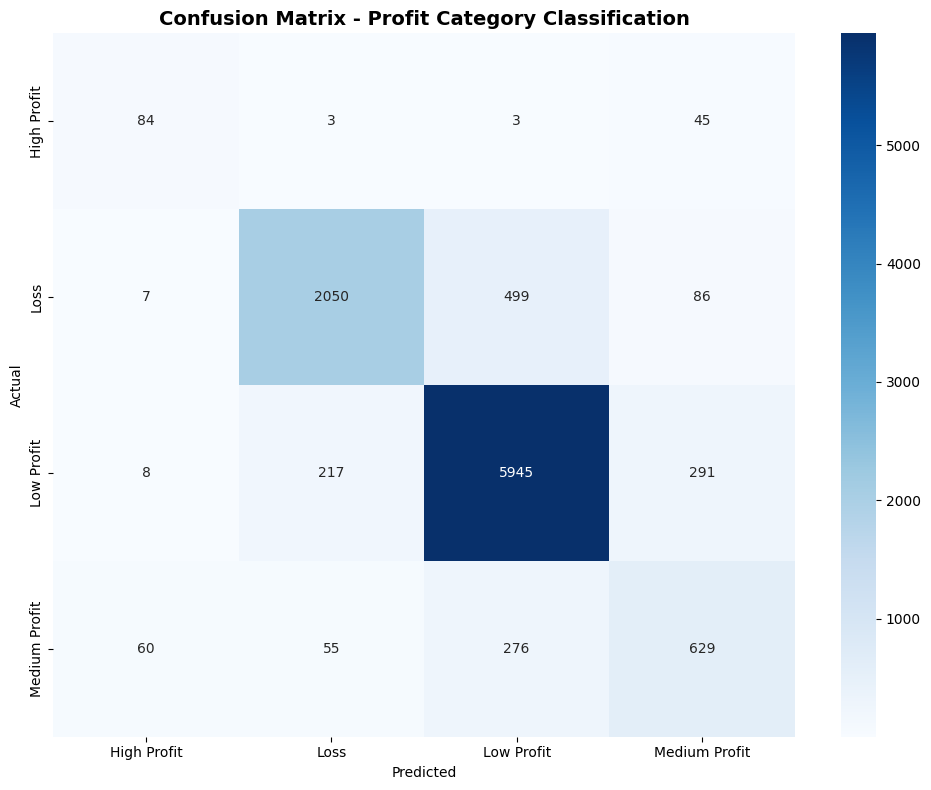

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Profit Category Classification', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Part 2: Prediction - Forecast Sales

In [10]:
prediction_features = ['Quantity', 'Discount', 'Shipping Cost', 
                      'Category', 'Segment', 'Ship Mode']
target_pred = 'Sales'

df_pred = df[prediction_features + [target_pred]].copy().dropna()
print(f"Dataset size: {len(df_pred)} rows")

Dataset size: 51290 rows


In [11]:
le_dict_pred = {}
for col in ['Category', 'Segment', 'Ship Mode']:
    le = LabelEncoder()
    df_pred[col] = le.fit_transform(df_pred[col])
    le_dict_pred[col] = le

print("Categorical variables encoded")

Categorical variables encoded


In [12]:
X_pred = df_pred[prediction_features]
y_pred_target = df_pred[target_pred]
X_train_pred, X_test_pred, y_train_pred, y_test_pred = train_test_split(
    X_pred, y_pred_target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pred)
X_test_scaled = scaler.transform(X_test_pred)
print("Features normalized")

Features normalized


In [13]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_pred)
y_pred_sales = lr_model.predict(X_test_scaled)

r2 = r2_score(y_test_pred, y_pred_sales)
mae = mean_absolute_error(y_test_pred, y_pred_sales)
rmse = np.sqrt(mean_squared_error(y_test_pred, y_pred_sales))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")

R² Score: 0.6596
Mean Absolute Error: $123.60
Root Mean Squared Error: $276.02


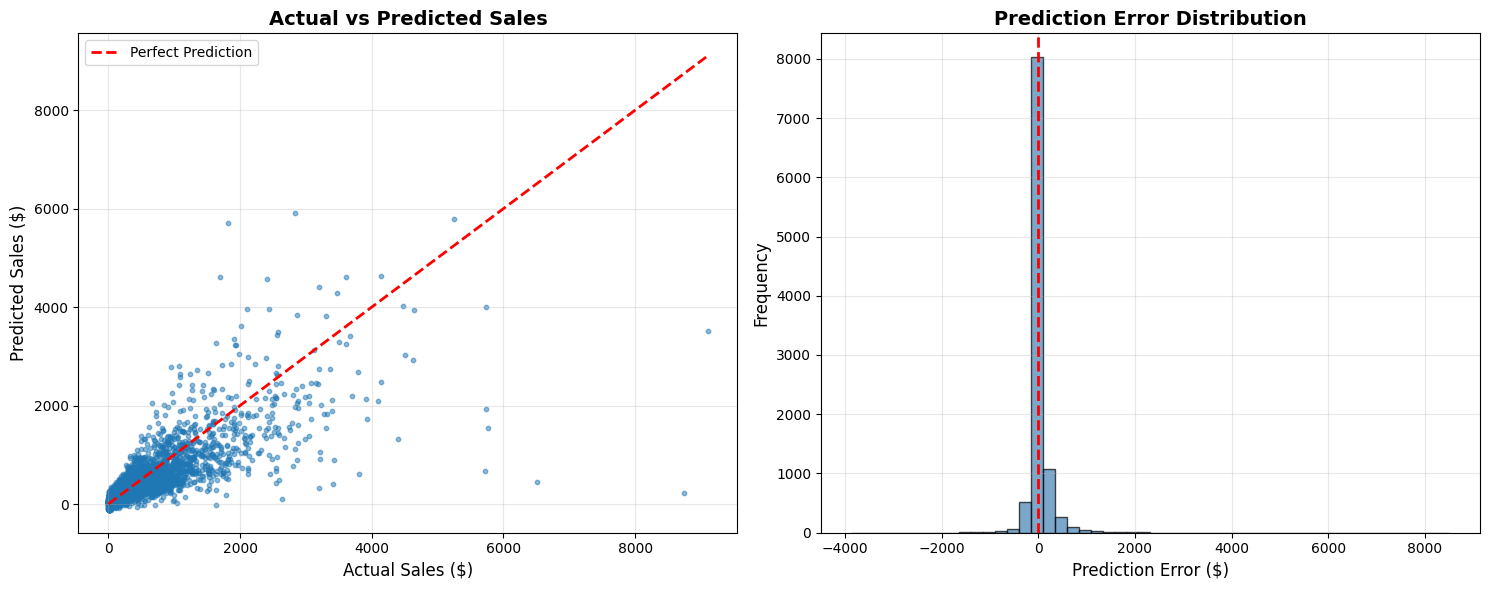

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test_pred, y_pred_sales, alpha=0.5, s=10)
axes[0].plot([y_test_pred.min(), y_test_pred.max()], 
             [y_test_pred.min(), y_test_pred.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales ($)', fontsize=12)
axes[0].set_ylabel('Predicted Sales ($)', fontsize=12)
axes[0].set_title('Actual vs Predicted Sales', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test_pred - y_pred_sales
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Prediction Error ($)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Prediction Error Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 3: Clustering - Customer Segmentation

In [17]:
customer_data = df.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Order ID': 'count',
    'Discount': 'mean'
}).reset_index()

customer_data.columns = ['Customer_ID', 'Total_Sales', 'Total_Profit', 
                         'Total_Quantity', 'Order_Count', 'Avg_Discount']

print(f"Analyzing {len(customer_data)} customers")
customer_data.head()

Analyzing 1590 customers


,Customer_ID,Total_Sales,Total_Profit,Total_Quantity,Order_Count,Avg_Discount
0,AA-10315,13747.41300,447.69050,145,42,0.103571
1,AA-10375,5884.19500,677.47740,139,42,0.166667
2,AA-10480,17695.58978,1516.47518,150,38,0.078474
3,AA-10645,15343.89070,3051.43900,267,73,0.125945
4,AA-315,2243.25600,535.56600,20,8,0.225000


In [18]:
clustering_features = ['Total_Sales', 'Total_Profit', 'Total_Quantity', 
                       'Order_Count', 'Avg_Discount']
X_cluster = customer_data[clustering_features]
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)
print("Features normalized")

Features normalized


In [20]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

cluster_summary = customer_data.groupby('Cluster')[clustering_features].mean()
sorted_clusters = cluster_summary.sort_values('Total_Sales').index
cluster_names = {0: 'Low Value', 1: 'Medium Value', 2: 'High Value', 3: 'VIP'}
cluster_mapping = {cluster: cluster_names[i] for i, cluster in enumerate(sorted_clusters)}
customer_data['Cluster_Name'] = customer_data['Cluster'].map(cluster_mapping)

print(f"Created {optimal_k} customer segments:")
for cluster_name in sorted_clusters:
    cluster_label = cluster_mapping[cluster_name]
    cluster_info = customer_data[customer_data['Cluster'] == cluster_name]
    print(f"  {cluster_label}: {len(cluster_info)} customers "
          f"(Avg Sales: ${cluster_info['Total_Sales'].mean():.2f})")

Created 4 customer segments:
  Low Value: 285 customers (Avg Sales: $1760.80)
  Medium Value: 532 customers (Avg Sales: $2411.36)
  High Value: 555 customers (Avg Sales: $11977.12)
  VIP: 218 customers (Avg Sales: $19314.34)


In [21]:
cluster_summary_full = customer_data.groupby('Cluster_Name')[clustering_features].mean()
cluster_summary_full['Customer_Count'] = customer_data.groupby('Cluster_Name').size()
print("Cluster Characteristics:")
cluster_summary_full.round(2)

Cluster Characteristics:


,Total_Sales,Total_Profit,Total_Quantity,Order_Count,Avg_Discount,Customer_Count
Cluster_Name,,,,,,
High Value,11977.12,1130.35,182.62,48.78,0.14,555
Low Value,1760.80,-262.56,29.78,12.78,0.34,285
Medium Value,2411.36,429.65,31.16,13.11,0.08,532
VIP,19314.34,3148.46,238.04,62.40,0.12,218


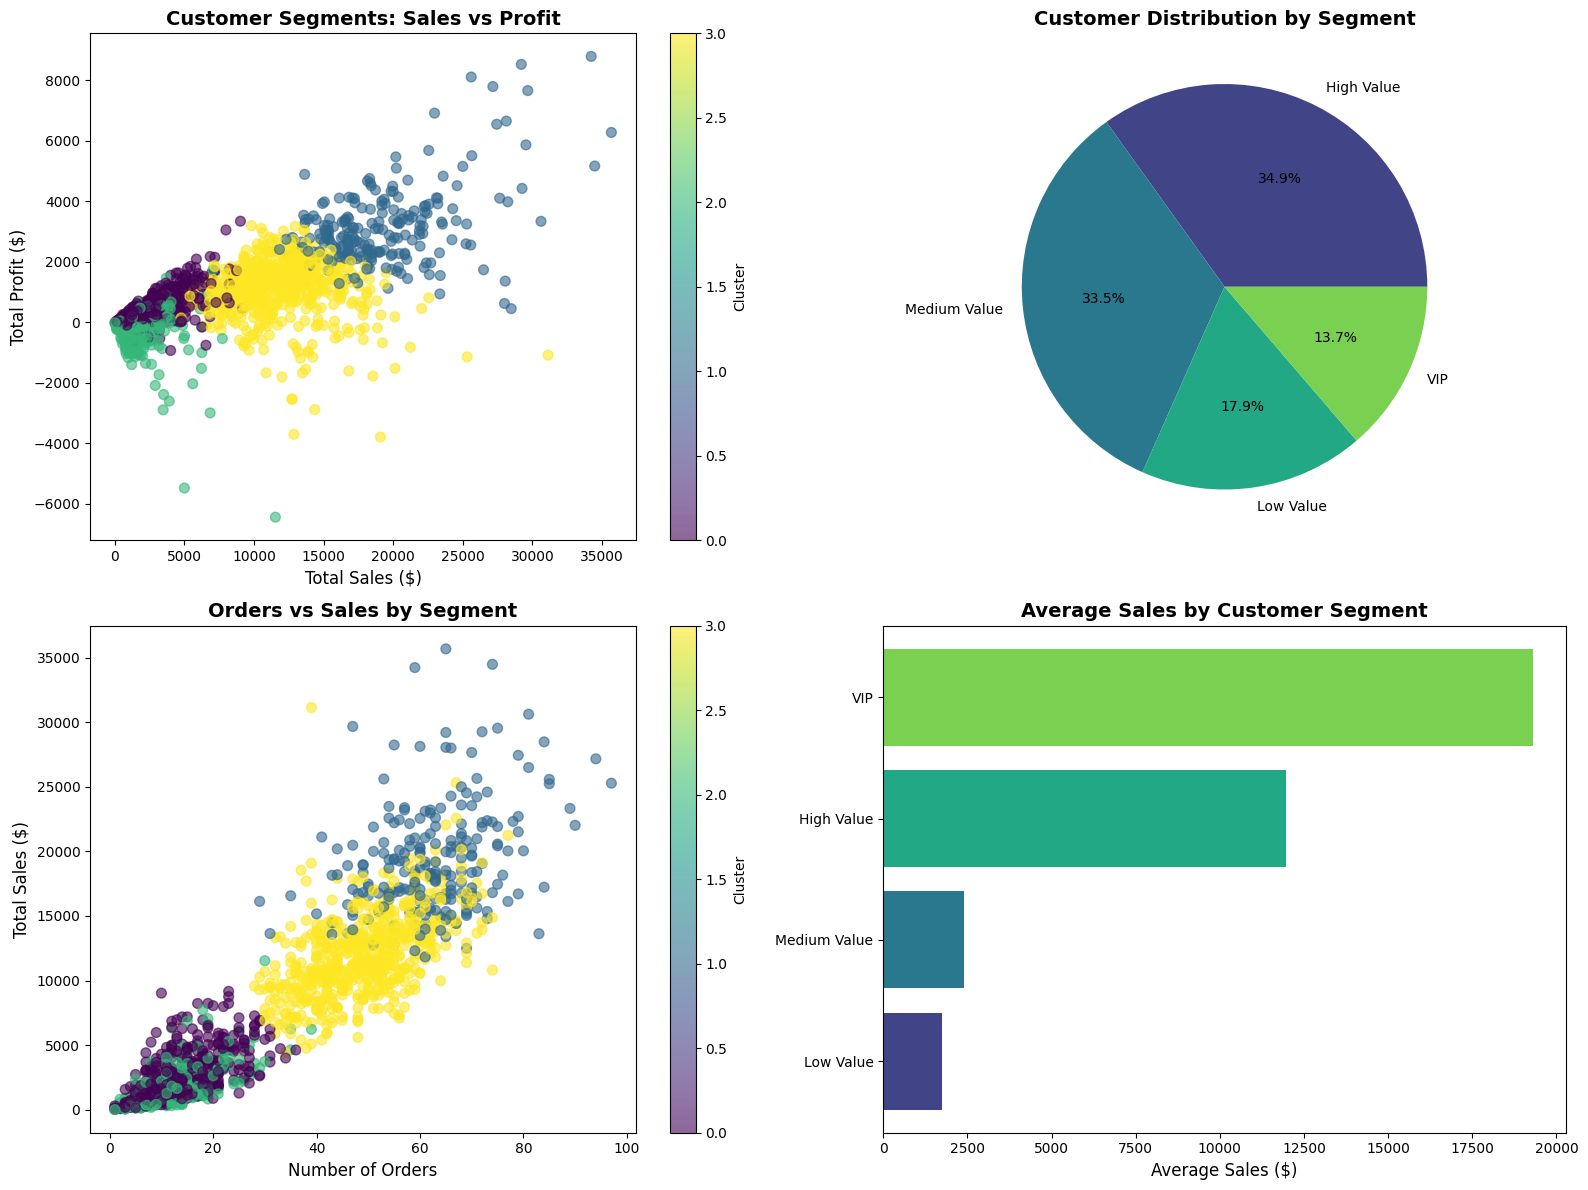

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scatter = axes[0, 0].scatter(customer_data['Total_Sales'], 
                             customer_data['Total_Profit'],
                             c=customer_data['Cluster'], 
                             cmap='viridis', 
                             s=50, alpha=0.6)
axes[0, 0].set_xlabel('Total Sales ($)', fontsize=12)
axes[0, 0].set_ylabel('Total Profit ($)', fontsize=12)
axes[0, 0].set_title('Customer Segments: Sales vs Profit', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster')

cluster_counts = customer_data['Cluster_Name'].value_counts()
axes[0, 1].pie(cluster_counts, labels=cluster_counts.index, autopct='%1.1f%%',
               colors=sns.color_palette('viridis', len(cluster_counts)))
axes[0, 1].set_title('Customer Distribution by Segment', fontsize=14, fontweight='bold')

scatter2 = axes[1, 0].scatter(customer_data['Order_Count'], 
                              customer_data['Total_Sales'],
                              c=customer_data['Cluster'], 
                              cmap='viridis', 
                              s=50, alpha=0.6)
axes[1, 0].set_xlabel('Number of Orders', fontsize=12)
axes[1, 0].set_ylabel('Total Sales ($)', fontsize=12)
axes[1, 0].set_title('Orders vs Sales by Segment', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1, 0], label='Cluster')

cluster_summary_plot = customer_data.groupby('Cluster_Name')['Total_Sales'].mean().sort_values()
axes[1, 1].barh(cluster_summary_plot.index, cluster_summary_plot.values, 
                color=sns.color_palette('viridis', len(cluster_summary_plot)))
axes[1, 1].set_xlabel('Average Sales ($)', fontsize=12)
axes[1, 1].set_title('Average Sales by Customer Segment', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()